# CodeAlpha Task 2 – Exploratory Data Analysis of Netflix Movies and TV Shows

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset.

The analysis focuses on understanding the structure and quality of the dataset, identifying missing values and duplicates, analyzing content types, release-year trends, ratings, countries, movie durations, and genres, and discovering meaningful patterns using Python and data visualization.

In [423]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Dataset

The dataset used for this project is the Netflix Movies and TV Shows dataset.

It contains information about movies and TV shows available on Netflix, including their type, title, director, cast, country, release year, rating, duration, genres, and description.

## 2. Understanding the Dataset

The dataset was examined to understand its rows, columns, variables, and data types.

In [424]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/netflix_data')

In [425]:
import os

os.listdir('/content/netflix_data')

['netflix_titles.csv']

In [426]:
df = pd.read_csv('/content/netflix_data/netflix_titles.csv')

In [427]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. Understanding the Dataset

The dataset was examined to understand its rows, columns, variables, and data types.

In [428]:
df.shape

(8807, 12)

In [429]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [430]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [431]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## 3. Data Cleaning

Missing values were checked in the dataset. Several columns contained missing values, especially director, cast, and country.

Instead of deleting these records, the missing values were replaced with meaningful labels such as "Not Available" and "Not Rated".

In [432]:
df.duplicated().sum()

np.int64(0)

In [433]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


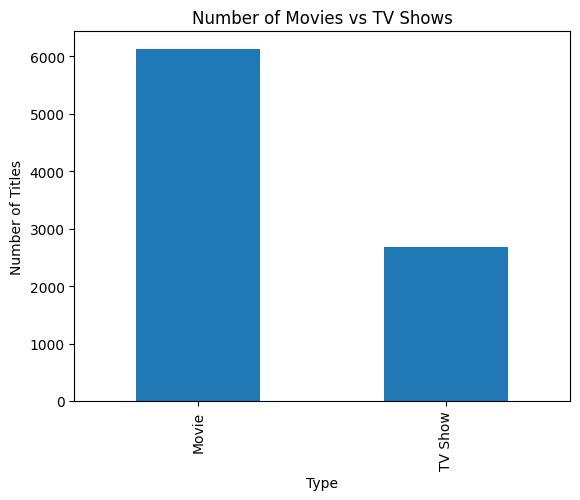

In [434]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')

plt.title('Number of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Number of Titles')
plt.show()

In [435]:
df['release_year'].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


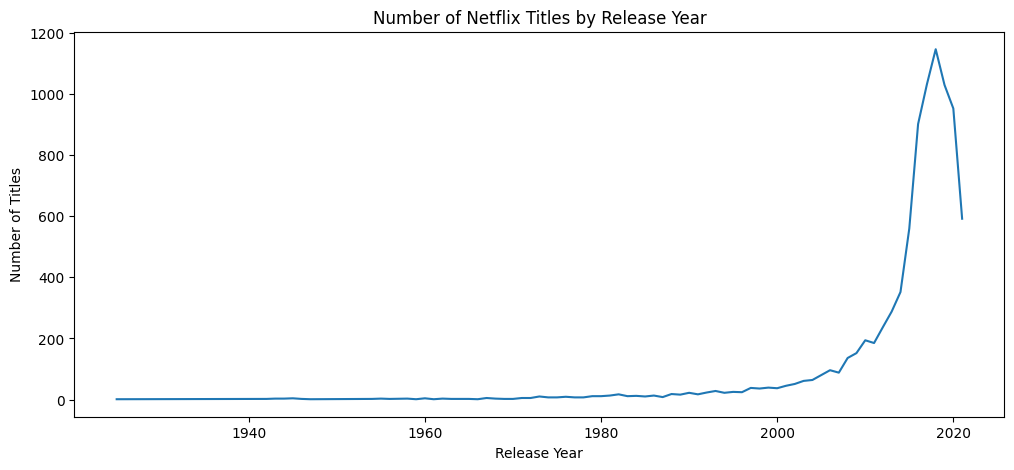

In [436]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values)
plt.title('Number of Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

In [437]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [438]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


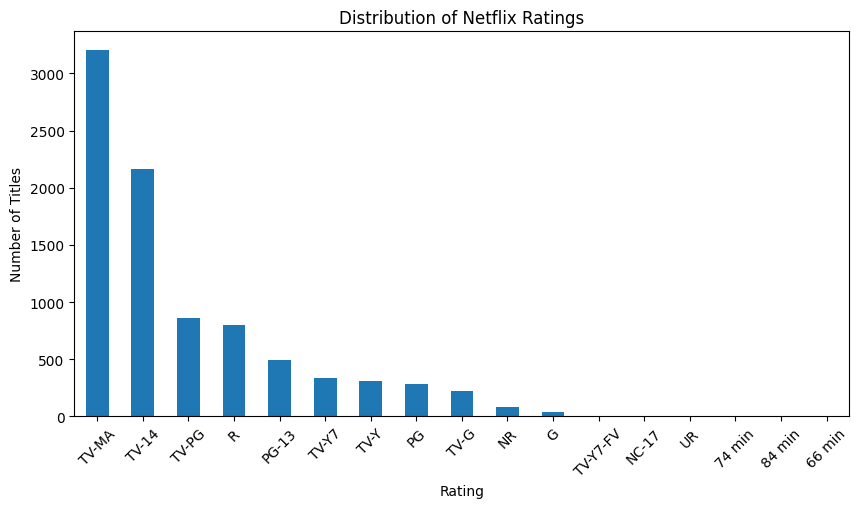

In [439]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(10, 5))
rating_counts.plot(kind='bar')
plt.title('Distribution of Netflix Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

In [440]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


In [441]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


In [442]:
df.groupby(['release_year', 'type']).size().unstack(fill_value=0).tail(15)

type,Movie,TV Show
release_year,,
2007,74,14
2008,113,23
2009,118,34
2010,154,40
2011,145,40
2012,173,64
2013,225,63
2014,264,88
2015,398,162


In [443]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


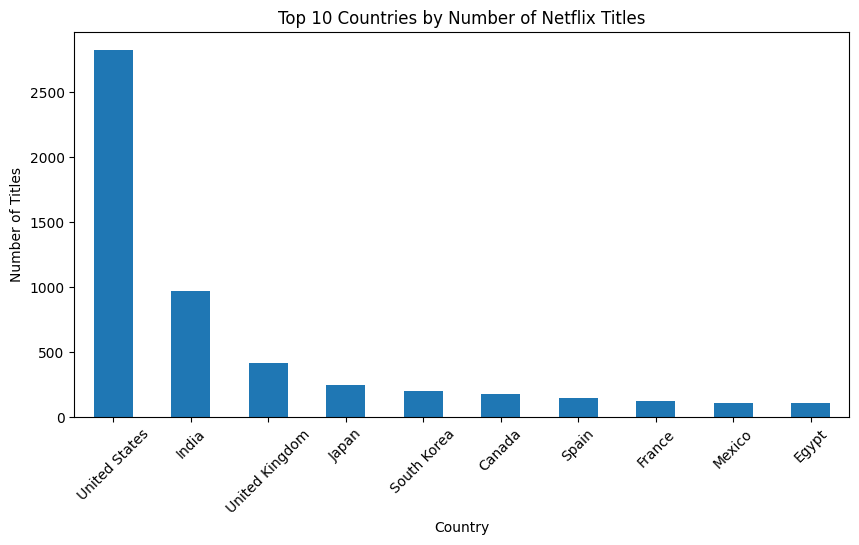

In [444]:
country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
country_counts.plot(kind='bar')
plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

In [445]:
df['duration'].value_counts().head(10)

,count
duration,
1 Season,1793
2 Seasons,425
3 Seasons,199
90 min,152
97 min,146
94 min,146
93 min,146
91 min,144
95 min,137


In [446]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_minutes'] = movies['duration'].str.replace(' min', '').astype(float)

movies['duration_minutes'].describe()

,duration_minutes
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


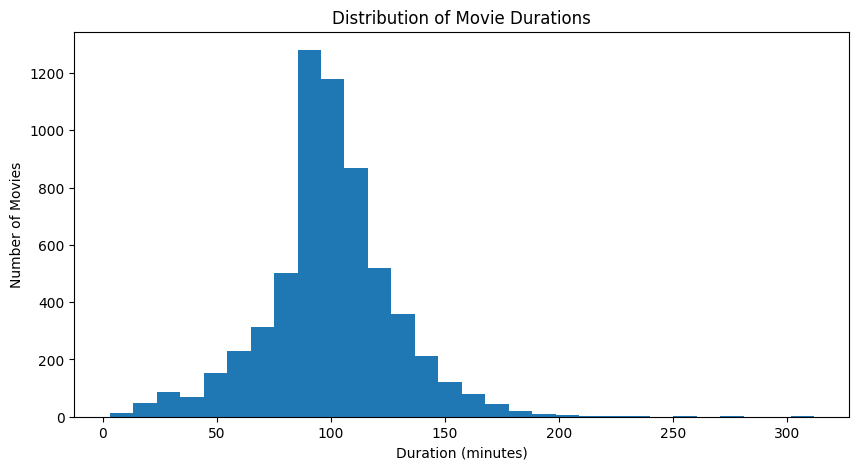

In [447]:
plt.figure(figsize=(10, 5))

plt.hist(movies['duration_minutes'], bins=30)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.show()

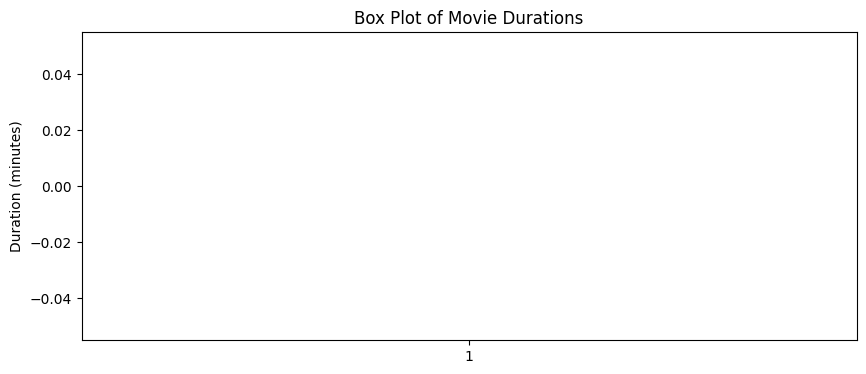

In [448]:
plt.figure(figsize=(10, 4))

plt.boxplot(movies['duration_minutes'])

plt.title('Box Plot of Movie Durations')
plt.ylabel('Duration (minutes)')

plt.show()

In [449]:
type_percentage = df['type'].value_counts(normalize=True) * 100
type_percentage

,proportion
type,
Movie,69.615079
TV Show,30.384921


In [450]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## 4. Checking for Duplicate Records

Duplicate records were checked to ensure that the dataset did not contain completely duplicated rows.

In [451]:
df['director'] = df['director'].fillna('Not Available')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Not Available')

In [452]:
df[['director', 'cast', 'country']].isnull().sum()

,0
director,0
cast,0
country,0


In [453]:
df['date_added'] = df['date_added'].fillna('Not Available')

In [454]:
df['rating'] = df['rating'].fillna('Not Available')

In [455]:
df['rating'].isnull().sum()

np.int64(0)

In [456]:
df['duration'] = df['duration'].fillna('Not Available')

In [457]:
df['duration'].isnull().sum()

np.int64(0)

In [458]:
df.isnull().sum().sum()

np.int64(0)

In [459]:
df.to_csv('/content/netflix_cleaned.csv', index=False)

In [460]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


In [461]:
genres = df['listed_in'].str.split(', ').explode()

genres.value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


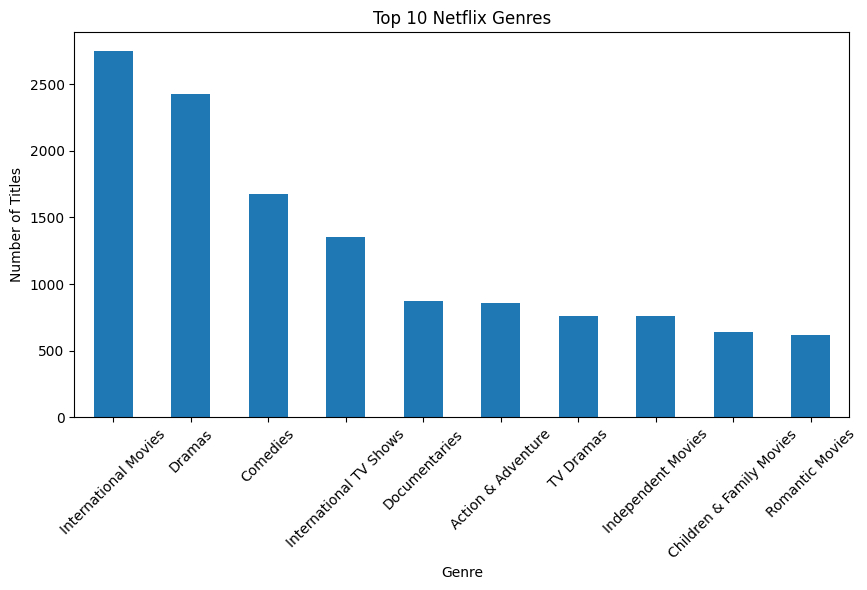

In [462]:
genre_counts = genres.value_counts().head(10)

plt.figure(figsize=(10, 5))
genre_counts.plot(kind='bar')

plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

## 6. Release Year Analysis

The release year of the titles was analyzed to identify trends in the amount of Netflix content released over different years.

In [463]:
year_counts = df['release_year'].value_counts().sort_index()
year_counts

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


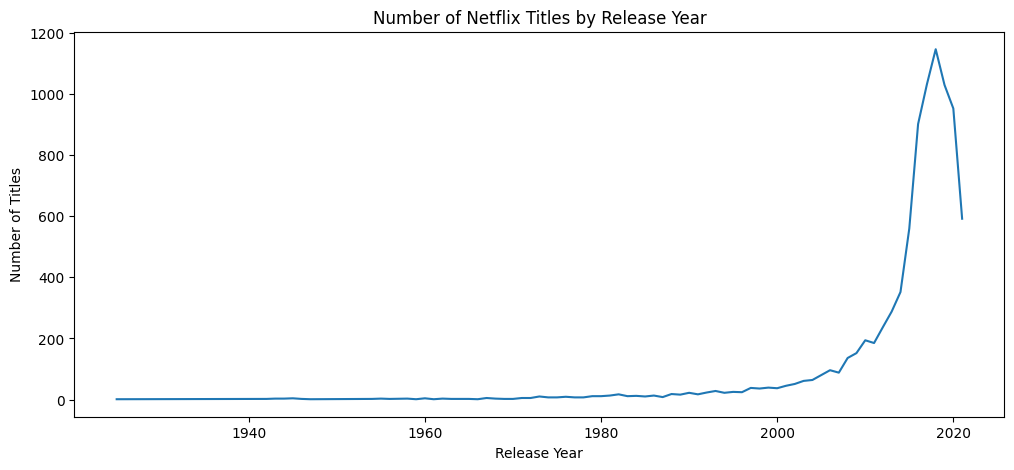

In [464]:
plt.figure(figsize=(12, 5))

plt.plot(year_counts.index, year_counts.values)

plt.title('Number of Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

### Finding

The dataset contains titles released over many decades, but a much larger number of titles are associated with recent years. The number of titles increases considerably from the 2010s, with particularly high numbers between 2017 and 2020.

## 7. Ratings Analysis

The ratings of Netflix titles were analyzed to understand the distribution of content across different audience ratings.

In [465]:
rating_counts = df['rating'].value_counts()
rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


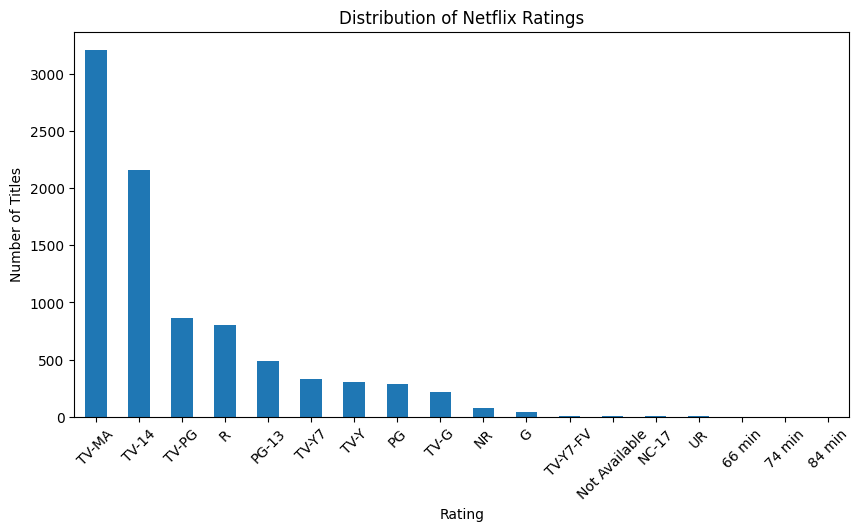

In [466]:
plt.figure(figsize=(10, 5))

rating_counts.plot(kind='bar')

plt.title('Distribution of Netflix Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

### Finding

The dataset contains Netflix titles across several different audience ratings. The bar chart shows the distribution of titles among the different rating categories.

## 8. Country Analysis

The country information was analyzed to identify the countries that have the highest number of Netflix titles in the dataset.

In [467]:
country_counts = df['country'].value_counts().head(10)
country_counts

,count
country,
United States,2818
India,972
Not Available,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


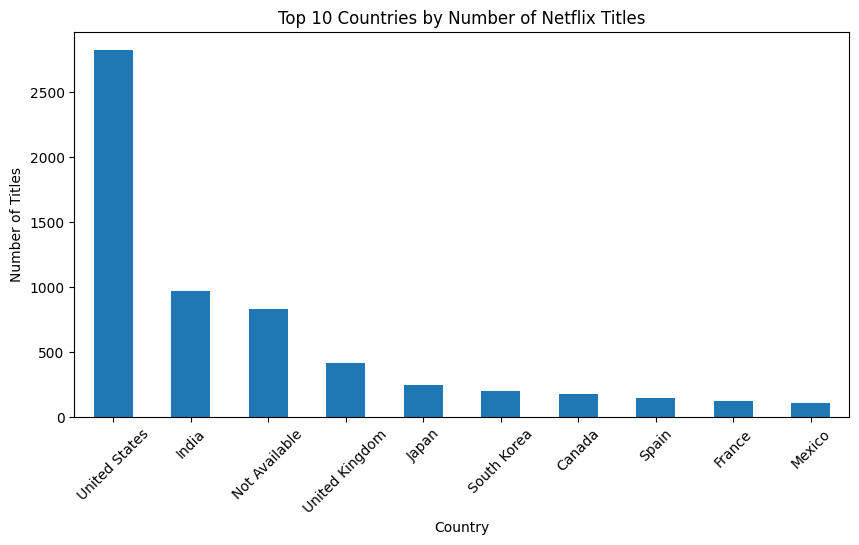

In [468]:
plt.figure(figsize=(10, 5))

country_counts.plot(kind='bar')

plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

### Finding

The United States has the highest number of Netflix titles in the dataset, followed by India and the United Kingdom. Japan, South Korea, Canada, Spain, France, Mexico, and Egypt are also among the top countries represented.

## 9. Movies vs TV Shows by Release Year

The number of movies and TV shows was compared across different release years to understand how the content distribution has changed over time.

In [469]:
year_type = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)
year_type.tail(15)

type,Movie,TV Show
release_year,,
2007,74,14
2008,113,23
2009,118,34
2010,154,40
2011,145,40
2012,173,64
2013,225,63
2014,264,88
2015,398,162


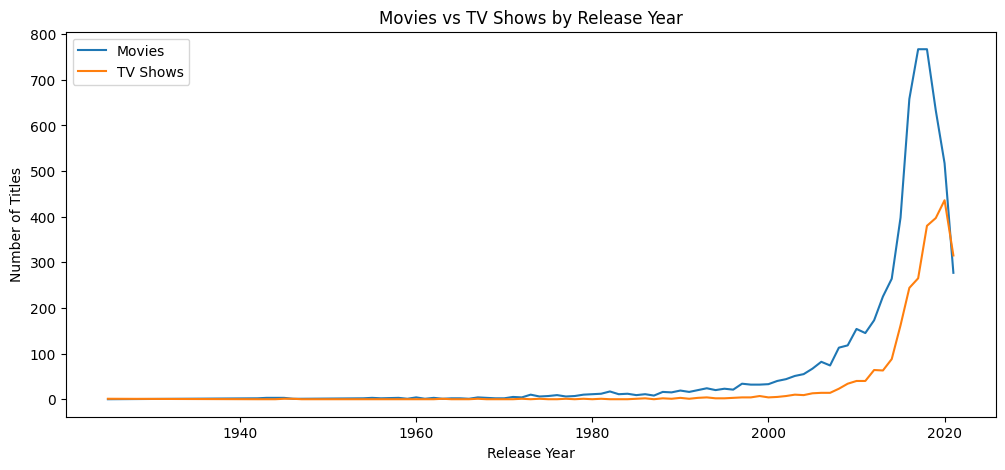

In [470]:
plt.figure(figsize=(12, 5))

plt.plot(year_type.index, year_type['Movie'], label='Movies')
plt.plot(year_type.index, year_type['TV Show'], label='TV Shows')

plt.title('Movies vs TV Shows by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.legend()
plt.show()

### Finding

Movies were more numerous than TV shows in most of the recent years. However, the number of TV shows increased considerably over time. In 2021, the dataset contains more TV shows than movies, with 315 TV shows compared with 277 movies.

## 10. Movie Duration Analysis

The duration of movies was analyzed to understand the typical length of Netflix movies and identify unusually short or long movies.

In [471]:
movie_durations = pd.to_numeric(
    df.loc[df['type'] == 'Movie', 'duration']
    .str.replace(' min', '', regex=False),
    errors='coerce'
).dropna()

movie_durations.describe()

,duration
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


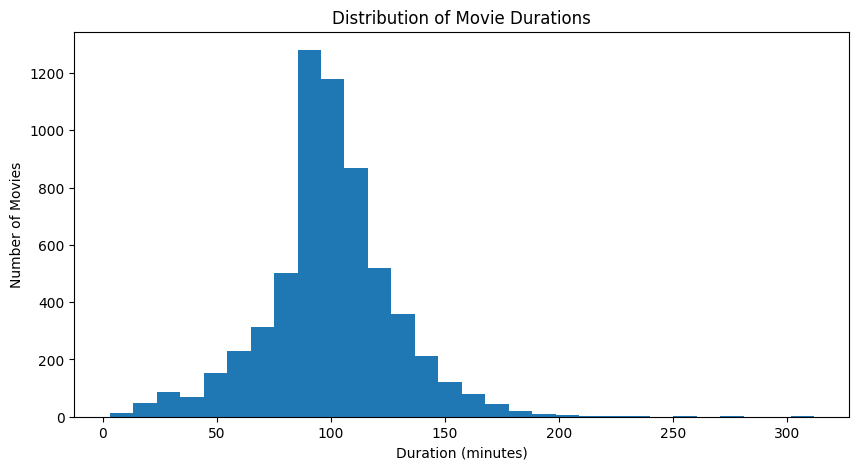

In [472]:
plt.figure(figsize=(10, 5))

plt.hist(movie_durations, bins=30)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.show()

### Finding

The average movie duration is approximately 99.6 minutes, while the median duration is 98 minutes. Most movies have durations between approximately 87 and 114 minutes. A few movies are much shorter or longer than the typical duration.

## 11. Outlier Analysis

A box plot was used to identify possible outliers in movie durations.

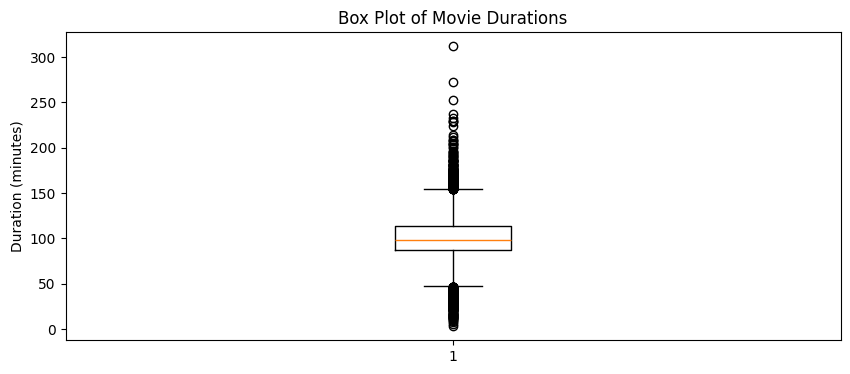

In [473]:
plt.figure(figsize=(10, 4))

plt.boxplot(movie_durations)

plt.title('Box Plot of Movie Durations')
plt.ylabel('Duration (minutes)')

plt.show()

### Finding

The box plot shows that some movies have unusually short or long durations compared with the majority of movies. These values can be considered potential outliers.

## 12. Genre Analysis

The genres of Netflix titles were analyzed to identify the most common types of content available on the platform.

In [474]:
genres = df['listed_in'].str.split(', ').explode()

genre_counts = genres.value_counts().head(10)

genre_counts

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


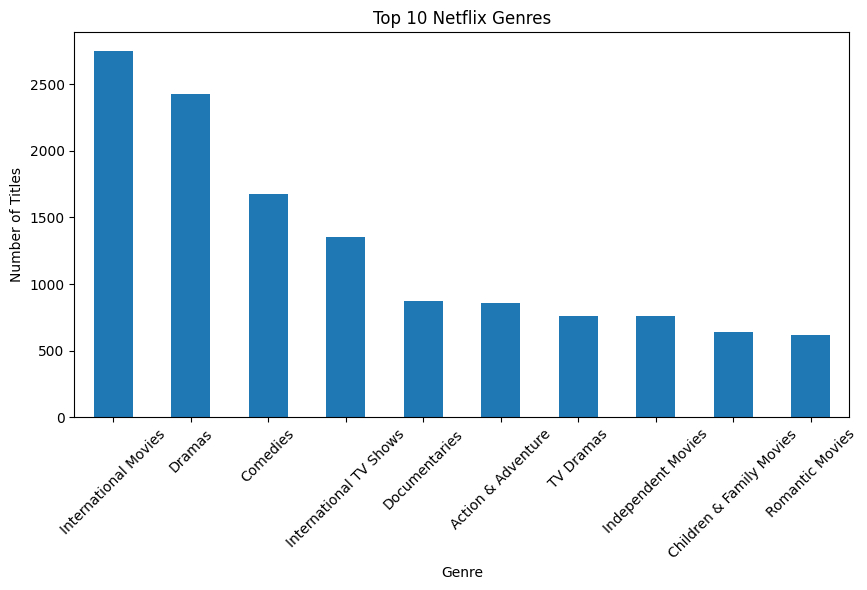

In [475]:
plt.figure(figsize=(10, 5))

genre_counts.plot(kind='bar')

plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

### Finding

International Movies, Dramas, and Comedies are among the most common genres in the dataset. The analysis shows that Netflix contains a wide variety of content categories.

## 13. Key Findings

The major findings from the Exploratory Data Analysis are:

1. The dataset contains 8,807 Netflix titles across 12 columns.

2. Movies are more common than TV shows, with 6,131 movies and 2,676 TV shows.

3. Recent years, particularly from 2017 to 2020, contain a large number of Netflix titles.

4. The United States has the highest number of country entries, followed by India and the United Kingdom.

5. The number of TV shows increased considerably over time, and in 2021 TV shows exceeded movies in the dataset.

6. The average movie duration is approximately 99.6 minutes, with a median of 98 minutes.

7. International Movies, Dramas, and Comedies are among the most common genres.

8. The dataset initially contained missing values in several columns, which were successfully handled during data cleaning.

9. No completely duplicated records were found in the dataset.

## 14. Conclusion

The Exploratory Data Analysis provided useful insights into the Netflix Movies and TV Shows dataset. The analysis showed that movies form the majority of the dataset, while TV shows have increased considerably in recent years.

The analysis also identified the most represented countries and genres and examined movie durations and possible outliers. Missing values were handled appropriately, and no completely duplicated records were found.

Overall, the EDA helped identify important trends, patterns, and characteristics of Netflix content using Python and data visualization.

In [476]:
df.to_csv('/content/netflix_cleaned.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
